# Assignment 2: Mastering Big Data Handling

**Group Name:** scubaa  
**Members:**
1. Mohamed Alif Fathi bin Abdul Latif 
2. Iman Abadi bin Mohd Nizwan

Dataset: [Kaggle: Anime Dataset 2023](https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset)

# 1. Setup

## 1.1 Import required libraries

In [1]:
# Standard
import os, time, gc, psutil, threading, random, zipfile

# Core libraries
import pandas as pd
import dask.dataframe as dd
import pyarrow as pa
import pyarrow.csv as pa_csv

# Visualisation
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

print("All libraries imported successfully")

All libraries imported successfully


## 1.2 Download dataset

In [2]:
# !pip install kaggle

Install kaggle library for downloading dataset

In [3]:
!kaggle datasets download -d dbdmobile/myanimelist-dataset

Dataset URL: https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset
License(s): DbCL-1.0
myanimelist-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


Before downloading the dataset, you need to set up the kaggle API (kaggle.json) by download and move the kaggle.json file into this path **C:\Users\<YourUsername>\.kaggle\kaggle.json**

In [4]:
zip_file = 'myanimelist-dataset.zip' 

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('anime_dataset')
    
print("Files extracted successfully!")

Files extracted successfully!


Extract the dataset files into anime_dataset folder

# 2. Dataset Introduction

## 2.1 Dataset size

In [5]:
FILE = "anime_dataset/final_animedataset.csv"

total_size_bytes = 0

size_bytes = os.path.getsize(FILE)
size_mb = size_bytes / (1024 * 1024)
size_gb = size_bytes / (1024 * 1024 * 1024)

total_size_bytes += size_bytes

print(f"{FILE}")
print(f"Size: {size_bytes} bytes")
print(f"Size: {size_mb:.2f} MB")
print(f"Size: {size_gb:.2f} GB")

anime_dataset/final_animedataset.csv
Size: 4549801910 bytes
Size: 4339.03 MB
Size: 4.24 GB


# 3. Dataset load and inspection

## 3.1 Load the file using chunking and 5 sample rows for initial inspection using Pandas

In [6]:
nrows = 5
chunksize = 10000

df_sample   = pd.read_csv(FILE, nrows=nrows)
total_rows  = 0
null_counts = pd.Series(0, index=df_sample.columns)

for chunk in pd.read_csv(FILE, chunksize=chunksize):
    total_rows  += len(chunk)
    null_counts += chunk.isnull().sum()

## 3.2 Display file summary

In [7]:
print("File Summary")
display(pd.DataFrame({
    "Property" : ["File", "Total Rows", "Total Columns"],
    "Value"    : [FILE, f"{total_rows:,}", len(df_sample.columns)]
}).set_index("Property"))

File Summary


,Value
Property,
File,anime_dataset/final_animedataset.csv
Total Rows,"35,305,695"
Total Columns,13


## 3.3 Schema and null counts

In [8]:
print("Schema & Null Counts")
display(pd.DataFrame({
    "Dtype"  : df_sample.dtypes,
    "Nulls"  : null_counts,
    "Null %" : (null_counts / total_rows * 100).round(1)
}))

Schema & Null Counts


,Dtype,Nulls,Null %
username,str,256,0.0
anime_id,int64,0,0.0
my_score,int64,0,0.0
user_id,int64,0,0.0
gender,str,0,0.0
title,str,0,0.0
type,str,0,0.0
source,str,0,0.0
score,float64,0,0.0
scored_by,int64,0,0.0


## 3.4 Sample Rows

In [9]:
print(f"Sample Rows (first {nrows})")
display(df_sample)

Sample Rows (first 5)


,username,anime_id,my_score,user_id,gender,title,type,source,score,scored_by,rank,popularity,genre
0,karthiga,21,9,2255153,Female,One Piece,TV,Manga,8.54,423868,91.0,35,"Action, Adventure, Comedy, Super Power, Drama,..."
1,karthiga,59,7,2255153,Female,Chobits,TV,Manga,7.53,175388,1546.0,188,"Sci-Fi, Comedy, Drama, Romance, Ecchi, Seinen"
2,karthiga,74,7,2255153,Female,Gakuen Alice,TV,Manga,7.77,33244,941.0,1291,"Comedy, School, Shoujo, Super Power"
3,karthiga,120,7,2255153,Female,Fruits Basket,TV,Manga,7.77,167968,939.0,222,"Slice of Life, Comedy, Drama, Romance, Fantasy..."
4,karthiga,178,7,2255153,Female,Ultra Maniac,TV,Manga,7.26,9663,2594.0,2490,"Magic, Comedy, Romance, School, Shoujo"


In [10]:
del df_sample, total_rows, null_counts
gc.collect()

1484

Clear resource before go to next operation

# 4. Strategies

## 4.1 Define function for measure performance

Benchmarks a loading strategy by tracking its execution time, before/after memory, and peak memory using a background monitoring thread.

In [11]:
def evaluate_performance(
    strategy_fn,
    strategy_name: str = "UnknownStrategy",
    *args,
    **kwargs
) -> dict:
    process = psutil.Process(os.getpid())

    # Baseline memory before
    baseline_memory = process.memory_info().rss
    peak_memory     = baseline_memory
    monitoring      = True

    def monitor_memory():
        nonlocal peak_memory
        while monitoring:
            mem = process.memory_info().rss
            peak_memory = max(peak_memory, mem)
            time.sleep(0.05)

    monitor_thread = threading.Thread(target=monitor_memory, daemon=True)
    monitor_thread.start()

    t0     = time.time()
    result = strategy_fn(*args, **kwargs)
    if hasattr(result, "compute"):
        result = result.compute()
    t1 = time.time()

    monitoring = False
    monitor_thread.join()

    # Capture after del
    after_memory = process.memory_info().rss

    peak_memory_mb  = max(0, (peak_memory    - baseline_memory) / (1024 ** 2))
    before_mb       = baseline_memory / (1024 ** 2)
    after_mb        = after_memory    / (1024 ** 2)

    del result
    gc.collect()
    time.sleep(2)

    metrics = {
        "name"                    : strategy_name,
        "total_time_s"            : round(t1 - t0, 4),
        "before_memory_mb"        : round(before_mb, 2),
        "after_memory_mb"         : round(after_mb, 2),
        "peak_memory_usage_mb"    : round(peak_memory_mb, 2)
    }

    print(f"\nStrategy : {strategy_name}")
    display(pd.DataFrame([{
        "Metric" : "Total Time (s)",
        "Value"  : f"{metrics['total_time_s']:.2f}",
    }, {
        "Metric" : "Before Memory (MB)",
        "Value"  : f"{metrics['before_memory_mb']:,.1f}",
    }, {
        "Metric" : "After Memory (MB)",
        "Value"  : f"{metrics['after_memory_mb']:,.1f}",
    }, {
        "Metric" : "Peak Memory (MB)",
        "Value"  : f"{metrics['peak_memory_usage_mb']:,.1f}",
    }]).set_index("Metric"))

    return metrics

## 4.2 Define function for measure performance in average

Runs evaluate_performance() three times and averages the results to reduce noise from caching or OS fluctuations.

In [12]:
def evaluate_performance_avg(
    strategy_fn,
    strategy_name: str = "UnknownStrategy",
    n: int = 3,
    *args,
    **kwargs
) -> dict:
    runs = []
    for i in range(n):
        print(f"  Run {i+1}/{n}...")
        metrics = evaluate_performance(strategy_fn, strategy_name, *args, **kwargs)
        runs.append(metrics)
        time.sleep(2)

    avg_metrics = {
        "name"                 : strategy_name,
        "total_time_s"         : round(sum(r["total_time_s"]          for r in runs) / n, 4),
        "before_memory_mb"     : round(sum(r["before_memory_mb"]      for r in runs) / n, 2),
        "after_memory_mb"      : round(sum(r["after_memory_mb"]       for r in runs) / n, 2),
        "peak_memory_usage_mb" : round(sum(r["peak_memory_usage_mb"]  for r in runs) / n, 2),
    }

    print(f"\nAVG RESULT ({n} runs) : {strategy_name}")
    display(pd.DataFrame([{
        "Metric" : "Total Time (s)",
        "Value"  : f"{avg_metrics['total_time_s']:.2f}",
    }, {
        "Metric" : "Before Memory (MB)",
        "Value"  : f"{avg_metrics['before_memory_mb']:,.1f}",
    }, {
        "Metric" : "After Memory (MB)",
        "Value"  : f"{avg_metrics['after_memory_mb']:,.1f}",
    }, {
        "Metric" : "Peak Memory (MB)",
        "Value"  : f"{avg_metrics['peak_memory_usage_mb']:,.1f}",
    }]).set_index("Metric"))

    return avg_metrics

## 4.3 Strategy Definition

Defines all 7 loading strategies to be tested: selecting columns, chunking, dtype optimisation, sampling, and baselines for Pandas, Dask, and PyArrow.

In [13]:
# Strategy 1: Load Less Data

def strategy_select_cols() -> pd.DataFrame:
    return pd.read_csv(FILE, usecols=["anime_id", "title", "score"])

# Strategy 2: Chunking

def strategy_chunked() -> pd.DataFrame:
    chunks = pd.read_csv(FILE, chunksize=500000)
    return pd.concat(chunks, ignore_index=True)

# Strategy 3: Data Type Optimisation

def strategy_optimized_dtypes() -> pd.DataFrame:
    dtype_map = {
        "anime_id" : "int32",
        "score"    : "float32",
        "episodes" : "Int16",
    }
    return pd.read_csv(FILE, dtype=dtype_map)

# Strategy 4: Sampling

def strategy_sampling() -> pd.DataFrame:
    skip_logic = lambda i: i > 0 and random.random() > 0.01
    return pd.read_csv(FILE, skiprows=skip_logic)

# Strategy 5: Parallel Processing with Scalable Libraries

# Pandas (for comparison)
def strategy_baseline_pandas() -> pd.DataFrame:
    return pd.read_csv(FILE, low_memory=False)

# Dask
def strategy_baseline_dask() -> dd.DataFrame:
    return dd.read_csv(FILE)

# PyArrow
def strategy_baseline_pyarrow() -> pa.Table:
    return pa_csv.read_csv(FILE)



In [14]:
results = []
results_parallel = []

Initialises two empty lists to store benchmark metrics for Pandas strategies and parallel library strategies separately.

## 4.4 Pandas baseline for comparison

In [15]:
metrics = evaluate_performance_avg(strategy_baseline_pandas, "Baseline (Pandas)", n=3)
results.append(metrics)
results_parallel.append(metrics)

  Run 1/3...

Strategy : Baseline (Pandas)


,Value
Metric,
Total Time (s),124.24
Before Memory (MB),191.3
After Memory (MB),"5,309.4"
Peak Memory (MB),"11,201.8"


  Run 2/3...

Strategy : Baseline (Pandas)


,Value
Metric,
Total Time (s),123.18
Before Memory (MB),132.7
After Memory (MB),"6,377.6"
Peak Memory (MB),"11,572.1"


  Run 3/3...

Strategy : Baseline (Pandas)


,Value
Metric,
Total Time (s),115.81
Before Memory (MB),133.4
After Memory (MB),"5,977.9"
Peak Memory (MB),"11,900.9"



AVG RESULT (3 runs) : Baseline (Pandas)


,Value
Metric,
Total Time (s),121.08
Before Memory (MB),152.5
After Memory (MB),"5,888.3"
Peak Memory (MB),"11,558.3"


Runs a plain pd.read_csv() three times as the reference point to compare all other strategies against.

## 4.5 Strategy 1: Load Less Data

In [16]:
print("Warming up disk cache...")
_ = pd.read_csv(FILE, nrows=1000)
del _             
gc.collect()      
time.sleep(3)     

metrics = evaluate_performance_avg(strategy_select_cols, "Load Less Data (Pandas)", n=3)

results.append(metrics)

Warming up disk cache...
  Run 1/3...

Strategy : Load Less Data (Pandas)


,Value
Metric,
Total Time (s),28.92
Before Memory (MB),137.1
After Memory (MB),"1,900.9"
Peak Memory (MB),"2,138.9"


  Run 2/3...

Strategy : Load Less Data (Pandas)


,Value
Metric,
Total Time (s),28.39
Before Memory (MB),306.1
After Memory (MB),"1,928.9"
Peak Memory (MB),"1,970.9"


  Run 3/3...

Strategy : Load Less Data (Pandas)


,Value
Metric,
Total Time (s),28.10
Before Memory (MB),328.1
After Memory (MB),"1,925.6"
Peak Memory (MB),"1,949.5"



AVG RESULT (3 runs) : Load Less Data (Pandas)


,Value
Metric,
Total Time (s),28.47
Before Memory (MB),257.1
After Memory (MB),"1,918.5"
Peak Memory (MB),"2,019.8"


## 4.6 Strategy 2: Chunking

In [17]:
metrics = evaluate_performance_avg(strategy_chunked, "Chunking (Pandas)", n=3)
results.append(metrics)

  Run 1/3...

Strategy : Chunking (Pandas)


,Value
Metric,
Total Time (s),54.87
Before Memory (MB),324.8
After Memory (MB),"6,520.3"
Peak Memory (MB),"8,060.9"


  Run 2/3...

Strategy : Chunking (Pandas)


,Value
Metric,
Total Time (s),54.60
Before Memory (MB),163.8
After Memory (MB),"6,517.3"
Peak Memory (MB),"8,123.8"


  Run 3/3...

Strategy : Chunking (Pandas)


,Value
Metric,
Total Time (s),55.09
Before Memory (MB),162.8
After Memory (MB),"6,508.9"
Peak Memory (MB),"8,217.3"



AVG RESULT (3 runs) : Chunking (Pandas)


,Value
Metric,
Total Time (s),54.85
Before Memory (MB),217.1
After Memory (MB),"6,515.5"
Peak Memory (MB),"8,134.0"


## 4.7 Strategy 3: Data Type Optimisation

In [18]:
metrics = evaluate_performance_avg(strategy_optimized_dtypes, "Data Type Optimization (Pandas)", n=3)
results.append(metrics)

  Run 1/3...

Strategy : Data Type Optimization (Pandas)


,Value
Metric,
Total Time (s),59.52
Before Memory (MB),153.1
After Memory (MB),"5,351.4"
Peak Memory (MB),"7,197.6"


  Run 2/3...

Strategy : Data Type Optimization (Pandas)


,Value
Metric,
Total Time (s),56.13
Before Memory (MB),306.1
After Memory (MB),"6,491.9"
Peak Memory (MB),"8,243.1"


  Run 3/3...

Strategy : Data Type Optimization (Pandas)


,Value
Metric,
Total Time (s),56.01
Before Memory (MB),356.0
After Memory (MB),"6,500.6"
Peak Memory (MB),"8,194.0"



AVG RESULT (3 runs) : Data Type Optimization (Pandas)


,Value
Metric,
Total Time (s),57.22
Before Memory (MB),271.7
After Memory (MB),"6,114.6"
Peak Memory (MB),"7,878.2"


## 4.8 Strategy 4: Sampling

In [19]:
metrics = evaluate_performance_avg(strategy_sampling, "Sampling (Pandas)", n=3)
results.append(metrics)

  Run 1/3...

Strategy : Sampling (Pandas)


,Value
Metric,
Total Time (s),21.79
Before Memory (MB),352.7
After Memory (MB),402.8
Peak Memory (MB),69.9


  Run 2/3...

Strategy : Sampling (Pandas)


,Value
Metric,
Total Time (s),21.99
Before Memory (MB),338.5
After Memory (MB),380.1
Peak Memory (MB),44.4


  Run 3/3...

Strategy : Sampling (Pandas)


,Value
Metric,
Total Time (s),21.72
Before Memory (MB),313.6
After Memory (MB),367.3
Peak Memory (MB),72.7



AVG RESULT (3 runs) : Sampling (Pandas)


,Value
Metric,
Total Time (s),21.83
Before Memory (MB),334.9
After Memory (MB),383.4
Peak Memory (MB),62.3


## 4.9 Visualization for comparison between four strategies

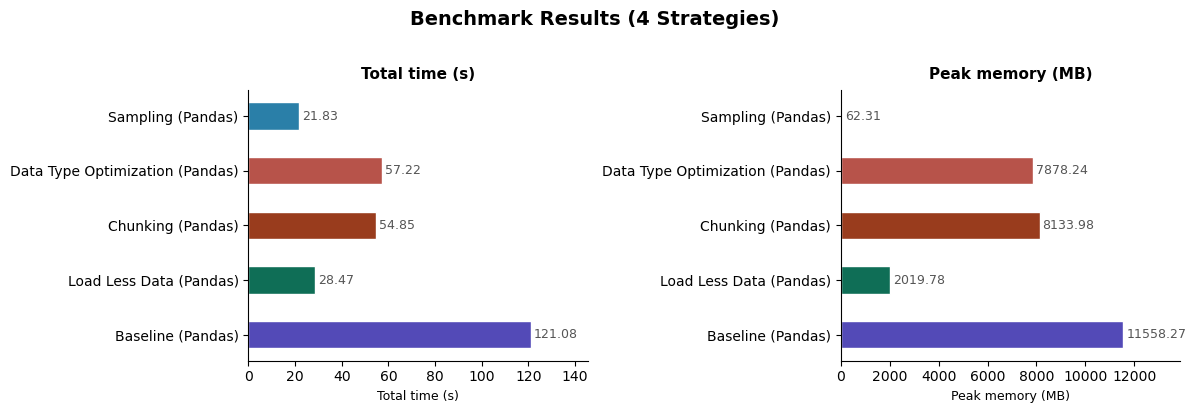

In [20]:
df = pd.DataFrame(results)

metrics = [
    ("total_time_s",         "Total time (s)"),
    ("peak_memory_usage_mb", "Peak memory (MB)"),
]
colors = ["#534AB7", "#0F6E56", "#993C1D", "#B7534A", "#2A7FA8", "#7A5C9E"]

names_seq = [r["name"] for r in results]
colors_seq = (colors * len(names_seq))[:len(names_seq)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Benchmark Results (4 Strategies)", fontsize=14, fontweight="bold", y=1.02)

for ax, (key, label) in zip(axes, metrics):
    values = [r.get(key, 0) for r in results]
    bars   = ax.barh(names_seq, values, color=colors_seq, edgecolor="white", height=0.5)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center", ha="left", fontsize=9, color="#555",
        )
    ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(label, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_xlim(0, max(values) * 1.2)

plt.tight_layout()
plt.savefig("benchmark_results_strategies.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.10 Strategy 5: Parallel Processing with Scalable Libraries

### 4.10.1 : Dask

In [21]:
metrics = evaluate_performance_avg(strategy_baseline_dask, "Baseline (Dask)", n=3)
results_parallel.append(metrics)

  Run 1/3...

Strategy : Baseline (Dask)


,Value
Metric,
Total Time (s),39.29
Before Memory (MB),215.7
After Memory (MB),"6,872.0"
Peak Memory (MB),"8,723.0"


  Run 2/3...

Strategy : Baseline (Dask)


,Value
Metric,
Total Time (s),38.14
Before Memory (MB),241.1
After Memory (MB),"6,854.5"
Peak Memory (MB),"8,709.8"


  Run 3/3...

Strategy : Baseline (Dask)


,Value
Metric,
Total Time (s),38.56
Before Memory (MB),228.9
After Memory (MB),"6,853.9"
Peak Memory (MB),"8,736.5"



AVG RESULT (3 runs) : Baseline (Dask)


,Value
Metric,
Total Time (s),38.66
Before Memory (MB),228.6
After Memory (MB),"6,860.1"
Peak Memory (MB),"8,723.1"


### 4.10.2 : PyArrow

In [22]:
metrics = evaluate_performance_avg(strategy_baseline_pyarrow, "Baseline (Pyarrow)", n=3)
results_parallel.append(metrics)

  Run 1/3...

Strategy : Baseline (Pyarrow)


,Value
Metric,
Total Time (s),17.75
Before Memory (MB),229.6
After Memory (MB),168.1
Peak Memory (MB),"9,895.0"


  Run 2/3...

Strategy : Baseline (Pyarrow)


,Value
Metric,
Total Time (s),14.97
Before Memory (MB),189.1
After Memory (MB),164.2
Peak Memory (MB),"11,485.7"


  Run 3/3...

Strategy : Baseline (Pyarrow)


,Value
Metric,
Total Time (s),15.44
Before Memory (MB),195.9
After Memory (MB),165.7
Peak Memory (MB),"11,576.9"



AVG RESULT (3 runs) : Baseline (Pyarrow)


,Value
Metric,
Total Time (s),16.05
Before Memory (MB),204.8
After Memory (MB),166.0
Peak Memory (MB),"10,985.9"


## 4.11 Visualization for comparison between Pandas, Dask and PyArrow (Full Load)

,name,total_time_s,before_memory_mb,after_memory_mb,peak_memory_usage_mb
0,Baseline (Pandas),121.0772,152.46,5888.28,11558.27
1,Baseline (Dask),38.6645,228.56,6860.14,8723.11
2,Baseline (Pyarrow),16.0540,204.84,165.99,10985.87


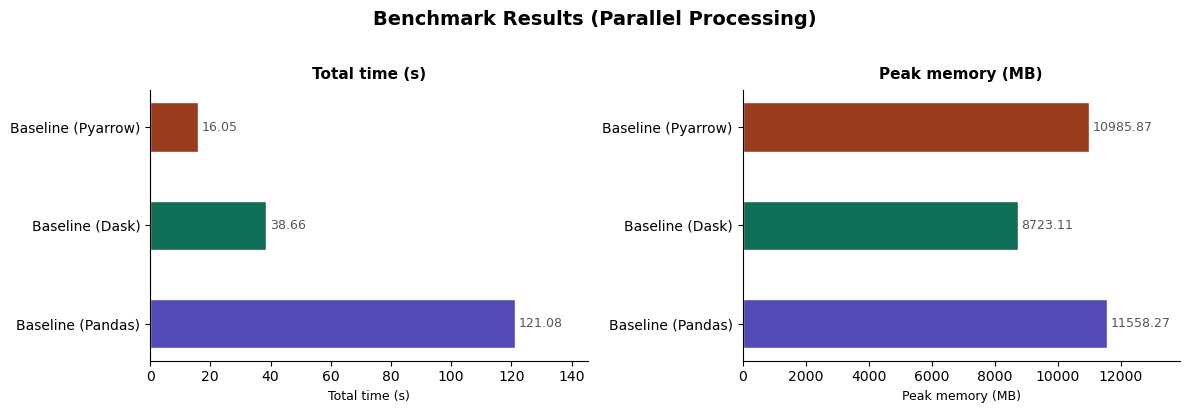

In [23]:
df = pd.DataFrame(results_parallel)

display(pd.DataFrame(results_parallel))

metrics = [
    ("total_time_s",         "Total time (s)"),
    ("peak_memory_usage_mb", "Peak memory (MB)"),
]
colors = ["#534AB7", "#0F6E56", "#993C1D"]

names_seq = [r["name"] for r in results_parallel]
colors_seq = (colors * len(names_seq))[:len(names_seq)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Benchmark Results (Parallel Processing)", fontsize=14, fontweight="bold", y=1.02)

for ax, (key, label) in zip(axes, metrics):
    values = [r.get(key, 0) for r in results_parallel]
    bars   = ax.barh(names_seq, values, color=colors_seq, edgecolor="white", height=0.5)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center", ha="left", fontsize=9, color="#555",
        )
    ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(label, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_xlim(0, max(values) * 1.2)

plt.tight_layout()
plt.savefig("benchmark_results_parallel.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Comparative Analysis

## 5.1 Define function for measure performance (Comparative)

An enhanced benchmark function that separately measures load time and processing time (a groupby aggregation), giving a clearer picture of where each library spends its time.

In [24]:
def evaluate_performance_library(
    load_fn,
    process_fn,
    strategy_name: str = "UnknownStrategy",
    *args,
    **kwargs
) -> dict:
    process = psutil.Process(os.getpid())

    baseline_memory = process.memory_info().rss
    peak_memory     = baseline_memory
    monitoring      = True

    def monitor_memory():
        nonlocal peak_memory
        while monitoring:
            mem = process.memory_info().rss
            peak_memory = max(peak_memory, mem)
            time.sleep(0.05)

    monitor_thread = threading.Thread(target=monitor_memory, daemon=True)
    monitor_thread.start()

    # --- Load ---
    t0     = time.time()
    data   = load_fn(*args, **kwargs)
    t1     = time.time()

    # --- Process ---
    t2     = time.time()
    result = process_fn(data)
    if hasattr(result, "compute"):
        result = result.compute()
    t3     = time.time()

    monitoring = False
    monitor_thread.join()

    after_memory        = process.memory_info().rss
    peak_memory_mb      = max(0, (peak_memory - baseline_memory) / (1024 ** 2))
    before_mb           = baseline_memory / (1024 ** 2)
    after_mb            = after_memory    / (1024 ** 2)
    load_time_s         = round(t1 - t0, 4)
    process_time_s      = round(t3 - t2, 4)
    total_time_s        = round(t3 - t0, 4)

    del data, result
    gc.collect()
    time.sleep(2)

    metrics = {
        "name"                 : strategy_name,
        "load_time_s"          : load_time_s,
        "process_time_s"       : process_time_s,
        "total_time_s"         : total_time_s,
        "before_memory_mb"     : round(before_mb, 2),
        "after_memory_mb"      : round(after_mb, 2),
        "peak_memory_usage_mb" : round(peak_memory_mb, 2),
    }

    print(f"\nStrategy : {strategy_name}")
    display(pd.DataFrame([{
        "Metric" : "Load Time (s)",
        "Value"  : f"{load_time_s:.2f}",
    }, {
        "Metric" : "Process Time (s)",
        "Value"  : f"{process_time_s:.2f}",
    }, {
        "Metric" : "Total Time (s)",
        "Value"  : f"{total_time_s:.2f}",
    }, {
        "Metric" : "Before Memory (MB)",
        "Value"  : f"{before_mb:,.1f}",
    }, {
        "Metric" : "After Memory (MB)",
        "Value"  : f"{after_mb:,.1f}",
    }, {
        "Metric" : "Peak Memory (MB)",
        "Value"  : f"{peak_memory_mb:,.1f}",
    }]).set_index("Metric"))
    print(f"{'='*40}")

    return metrics

## 5.2 Define function for measure performance (Comparative) in average

Runs the library benchmark 3 times and averages load, process, and total times.

In [25]:
def evaluate_performance_library_avg(
    load_fn,
    process_fn,
    strategy_name: str = "UnknownStrategy",
    n: int = 3,
    *args,
    **kwargs
) -> dict:
    runs = []
    for i in range(n):
        print(f"  Run {i+1}/{n}...")
        metrics = evaluate_performance_library(load_fn, process_fn, strategy_name, *args, **kwargs)
        runs.append(metrics)
        time.sleep(2)

    avg_metrics = {
        "name"                 : strategy_name,
        "load_time_s"          : round(sum(r["load_time_s"]          for r in runs) / n, 4),
        "process_time_s"       : round(sum(r["process_time_s"]       for r in runs) / n, 4),
        "total_time_s"         : round(sum(r["total_time_s"]         for r in runs) / n, 4),
        "before_memory_mb"     : round(sum(r["before_memory_mb"]     for r in runs) / n, 2),
        "after_memory_mb"      : round(sum(r["after_memory_mb"]      for r in runs) / n, 2),
        "peak_memory_usage_mb" : round(sum(r["peak_memory_usage_mb"] for r in runs) / n, 2),
    }

    print(f"\nAVG RESULT ({n} runs) : {strategy_name}")
    display(pd.DataFrame([{
        "Metric" : "Avg Load Time (s)",
        "Value"  : f"{avg_metrics['load_time_s']:.2f}",
    }, {
        "Metric" : "Avg Process Time (s)",
        "Value"  : f"{avg_metrics['process_time_s']:.2f}",
    }, {
        "Metric" : "Avg Total Time (s)",
        "Value"  : f"{avg_metrics['total_time_s']:.2f}",
    }, {
        "Metric" : "Avg Before Memory (MB)",
        "Value"  : f"{avg_metrics['before_memory_mb']:,.1f}",
    }, {
        "Metric" : "Avg After Memory (MB)",
        "Value"  : f"{avg_metrics['after_memory_mb']:,.1f}",
    }, {
        "Metric" : "Avg Peak Memory (MB)",
        "Value"  : f"{avg_metrics['peak_memory_usage_mb']:,.1f}",
    }]).set_index("Metric"))

    return avg_metrics

In [26]:
results_library = []

Initialises empty list to store benchmark metrics for three Libraries

## 5.3 Full load with Pandas

In [27]:
# Pandas
def load_pandas():
    return pd.read_csv(FILE, low_memory=False)

def process_pandas(df):
    return df.groupby("genre")["score"].mean()

metrics = evaluate_performance_library_avg(load_pandas, process_pandas, "Pandas", n=3)
results_library.append(metrics)

  Run 1/3...

Strategy : Pandas


,Value
Metric,
Load Time (s),165.26
Process Time (s),1.91
Total Time (s),167.17
Before Memory (MB),213.7
After Memory (MB),"6,364.5"
Peak Memory (MB),"11,489.3"


  Run 2/3...

Strategy : Pandas


,Value
Metric,
Load Time (s),143.85
Process Time (s),1.92
Total Time (s),145.77
Before Memory (MB),187.2
After Memory (MB),"6,401.4"
Peak Memory (MB),"11,041.1"


  Run 3/3...

Strategy : Pandas


,Value
Metric,
Load Time (s),166.30
Process Time (s),1.97
Total Time (s),168.27
Before Memory (MB),168.1
After Memory (MB),"5,952.3"
Peak Memory (MB),"11,815.8"



AVG RESULT (3 runs) : Pandas


,Value
Metric,
Avg Load Time (s),158.47
Avg Process Time (s),1.93
Avg Total Time (s),160.40
Avg Before Memory (MB),189.7
Avg After Memory (MB),"6,239.4"
Avg Peak Memory (MB),"11,448.7"


## 5.4 Full load with PyArrow

In [28]:
# PyArrow
def load_pyarrow():
    return pa_csv.read_csv(FILE)

def process_pyarrow(table):
    import pyarrow.compute as pc
    # groupby aggregation
    return table.group_by("genre").aggregate([("score", "mean")])

metrics = evaluate_performance_library_avg(load_pyarrow, process_pyarrow, "PyArrow", n=3)
results_library.append(metrics)

  Run 1/3...

Strategy : PyArrow


,Value
Metric,
Load Time (s),15.53
Process Time (s),0.50
Total Time (s),16.03
Before Memory (MB),168.9
After Memory (MB),"1,898.9"
Peak Memory (MB),"11,529.4"


  Run 2/3...

Strategy : PyArrow


,Value
Metric,
Load Time (s),18.74
Process Time (s),0.48
Total Time (s),19.22
Before Memory (MB),210.8
After Memory (MB),"1,908.8"
Peak Memory (MB),"11,368.8"


  Run 3/3...

Strategy : PyArrow


,Value
Metric,
Load Time (s),17.07
Process Time (s),0.51
Total Time (s),17.58
Before Memory (MB),212.8
After Memory (MB),"1,907.7"
Peak Memory (MB),"11,513.0"



AVG RESULT (3 runs) : PyArrow


,Value
Metric,
Avg Load Time (s),17.12
Avg Process Time (s),0.49
Avg Total Time (s),17.61
Avg Before Memory (MB),197.5
Avg After Memory (MB),"1,905.1"
Avg Peak Memory (MB),"11,470.4"


## 5.5 Full load with Dask

In [29]:
# Dask
def load_dask():
    return dd.read_csv(FILE)

def process_dask(df):
    return df.groupby("genre")["score"].mean()
    
metrics = evaluate_performance_library_avg(load_dask, process_dask, "Dask", n=3)
results_library.append(metrics)

  Run 1/3...

Strategy : Dask


,Value
Metric,
Load Time (s),0.08
Process Time (s),101.97
Total Time (s),102.05
Before Memory (MB),218.4
After Memory (MB),298.2
Peak Memory (MB),"2,819.1"


  Run 2/3...

Strategy : Dask


,Value
Metric,
Load Time (s),0.03
Process Time (s),98.69
Total Time (s),98.72
Before Memory (MB),298.2
After Memory (MB),297.4
Peak Memory (MB),"2,567.0"


  Run 3/3...

Strategy : Dask


,Value
Metric,
Load Time (s),0.03
Process Time (s),98.12
Total Time (s),98.15
Before Memory (MB),295.4
After Memory (MB),296.2
Peak Memory (MB),"2,713.9"



AVG RESULT (3 runs) : Dask


,Value
Metric,
Avg Load Time (s),0.04
Avg Process Time (s),99.59
Avg Total Time (s),99.64
Avg Before Memory (MB),270.6
Avg After Memory (MB),297.3
Avg Peak Memory (MB),"2,700.0"


In [30]:
display(pd.DataFrame(results_library))

,name,load_time_s,process_time_s,total_time_s,before_memory_mb,after_memory_mb,peak_memory_usage_mb
0,Pandas,158.4722,1.9323,160.4045,189.68,6239.37,11448.73
1,PyArrow,17.1152,0.4947,17.6099,197.52,1905.14,11470.42
2,Dask,0.0444,99.5928,99.6371,270.65,297.26,2700.01


Displays load, process, and total times for all three libraries in one table.

## 5.6 Visualization

Plots a 2×2 grid of horizontal bar charts comparing Pandas, PyArrow, and Dask across load time, process time, total time, and peak memory, then saves it as a PNG.

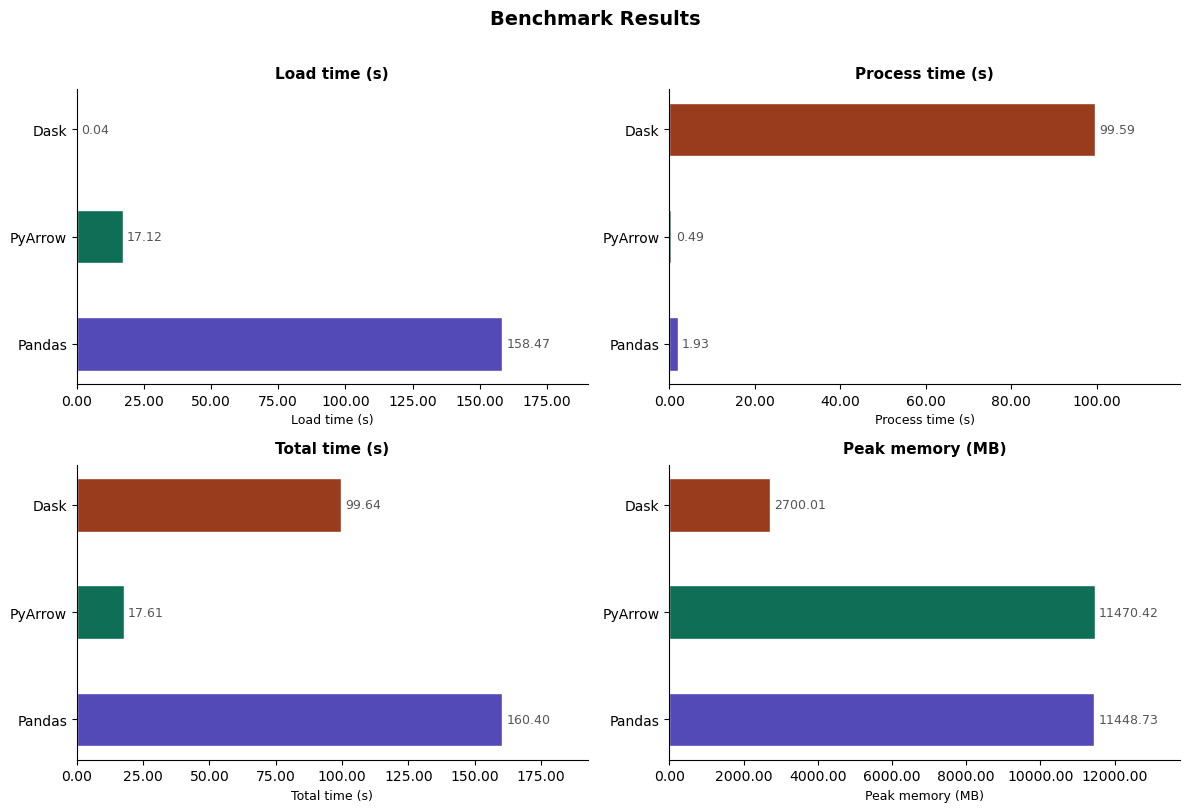

In [31]:
metrics = [
    ("load_time_s",          "Load time (s)"),
    ("process_time_s",       "Process time (s)"),
    ("total_time_s",         "Total time (s)"),
    ("peak_memory_usage_mb", "Peak memory (MB)"),
]

names  = [r["name"] for r in results_library]
colors = ["#534AB7", "#0F6E56", "#993C1D"]  # one per strategy, extend if needed
colors = (colors * len(names))[:len(names)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Benchmark Results", fontsize=14, fontweight="bold", y=1.01)
axes = axes.flatten()

for ax, (key, label) in zip(axes, metrics):
    values = [r.get(key, 0) for r in results_library]
    bars   = ax.barh(names, values, color=colors, edgecolor="white", height=0.5)

    # value labels at end of each bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center", ha="left", fontsize=9, color="#555"
        )

    ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(label, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="y", labelsize=10)
    ax.set_xlim(0, max(values) * 1.2)  # headroom for labels

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()